# Supervised Model Evaluation

## Final Relief Model Evaluation


## Notebook Overview

This evaluation notebook reviews the final relief-oriented Random Forest using the same current relief dataset for now. It mirrors the final development choices:

- the positive class is `Closed with monetary relief` only
- geography is excluded from the final modeling set
- the notebook is the all-records baseline that can score complaints with or without narratives
- simple narrative indicators are kept, including sentiment
- topic-cluster features are optional and will be used automatically if they exist in the dataset later


### Evaluation Metrics

Because this is still a classification problem with two response outcomes, we need more than accuracy to understand model quality. This evaluation reports:

- `accuracy` for overall correctness
- `precision` for how often predicted untimely cases are truly untimely
- `recall` for how many true untimely cases are captured
- `f1` as the primary model-selection metric because it balances precision and recall
- `roc_auc` to summarize ranking quality across thresholds
- `average_precision` because precision-recall behavior is informative under heavy imbalance
- `balanced_accuracy` so minority-class performance is not washed out by the majority class

Per the project requirements, model-family comparison should rely on cross-validated summary statistics. In this notebook, the saved development results provide that comparison, while the deeper evaluation focuses only on the selected Random Forest.


In [1]:
import ast
import os
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "consumer_banking_relief.parquet"
COMPARISON_PATH = PROJECT_ROOT / "output_tables" / "final_relief_supervised_model_comparison.csv"
MODEL_ARTIFACT_PATH = PROJECT_ROOT / "data" / "processed" / "best_final_relief_response_model.joblib"
VISUALS_DIR = PROJECT_ROOT / "visuals"
VISUALS_DIR.mkdir(exist_ok=True)
OUTPUT_TABLES_DIR = PROJECT_ROOT / "output_tables"
OUTPUT_TABLES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 5
FAST_CV_FOLDS = 3
MAX_MODEL_ROWS = 120000
N_JOBS = min(4, max(1, (os.cpu_count() or 2) - 1))

assert DATA_PATH.exists(), f"Expected source parquet at {DATA_PATH}"
raw_df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(raw_df):,} banking complaints from {DATA_PATH.name}")


Loaded 1,123,191 banking complaints from consumer_banking_relief.parquet


### Model Comparison

The development notebook compared four model families using cross-validated metrics. We reload that saved comparison here so the overall-results section remains concise and consistent, then narrow the rest of the notebook to the selected Random Forest.


In [2]:
if COMPARISON_PATH.exists():
    comparison_df = pd.read_csv(COMPARISON_PATH)
    display(comparison_df)
    rf_comparison_row = comparison_df.loc[comparison_df["model_family"].eq("Random Forest")].copy()
    comparison_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_model_family_comparison.csv", index=False)
else:
    comparison_df = None
    rf_comparison_row = pd.DataFrame()
    print("Saved comparison table not found. Run the development notebook first if you want to display the model-family comparison here.")

rf_comparison_row


,model_family,best_params,cv_mean_accuracy,cv_std_accuracy,cv_mean_average_precision,cv_std_average_precision,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_f1,cv_std_f1,cv_mean_balanced_accuracy,cv_std_balanced_accuracy,holdout_accuracy,holdout_average_precision,holdout_roc_auc,holdout_recall,holdout_precision,holdout_f1,holdout_balanced_accuracy
0,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.795010,0.003485,0.361438,0.008579,0.813170,0.004696,0.598813,0.009476,0.325006,0.005601,0.421308,0.006284,0.710875,0.004913,0.793292,0.364464,0.816504,0.603477,0.323477,0.421188,0.711896
1,Logistic Regression,{'model__C': 0.15},0.687750,0.001850,0.350740,0.009489,0.811304,0.003903,0.800703,0.004861,0.257684,0.001826,0.389892,0.002615,0.736188,0.002943,0.686042,0.345970,0.813089,0.814109,0.258657,0.392584,0.740959
2,Support Vector Machine,{'model__C': 1.0},0.679927,0.001664,0.350477,0.009813,0.811140,0.004091,0.809899,0.004833,0.254007,0.001447,0.386725,0.002106,0.735663,0.002529,0.678625,0.344617,0.812827,0.824473,0.255438,0.390036,0.741167
3,KNN,"{'model__n_neighbors': 71, 'model__p': 1, 'mod...",0.745000,0.004492,0.215813,0.007613,0.689827,0.007291,0.426423,0.009572,0.224558,0.005132,0.294160,0.005932,0.608383,0.004710,0.743792,0.217072,0.696361,0.445336,0.228787,0.302281,0.615809


,model_family,best_params,cv_mean_accuracy,cv_std_accuracy,cv_mean_average_precision,cv_std_average_precision,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_f1,cv_std_f1,cv_mean_balanced_accuracy,cv_std_balanced_accuracy,holdout_accuracy,holdout_average_precision,holdout_roc_auc,holdout_recall,holdout_precision,holdout_f1,holdout_balanced_accuracy
0,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.79501,0.003485,0.361438,0.008579,0.81317,0.004696,0.598813,0.009476,0.325006,0.005601,0.421308,0.006284,0.710875,0.004913,0.793292,0.364464,0.816504,0.603477,0.323477,0.421188,0.711896


Even before the deeper analysis, the development comparison matters for the report because it shows that the selected model was not chosen from intuition alone. In the final monetary-relief workflow, the comparison is especially useful because we intentionally removed geography and added lightweight narrative sentiment, so the evaluation notebook can test whether those design choices hold up once we look at the Random Forest in detail.


### Best Model Deep Dive

To keep evaluation consistent with development, we rebuild the same feature set and train/test split used in the development notebook. We keep only simple narrative indicators here, since more advanced narrative feature generation is being handled separately.


In [3]:
def make_one_hot_encoder():
    kwargs = {"handle_unknown": "ignore"}
    try:
        return OneHotEncoder(sparse_output=True, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse=True, **kwargs)


POSITIVE_RELIEF_VALUES = ["Closed with monetary relief"]
TOPIC_CLUSTER_CANDIDATES = [
    "narrative_topic_cluster",
    "topic_cluster",
    "complaint_topic_cluster",
    "narrative_cluster",
]
POSITIVE_WORDS = {
    "help",
    "helped",
    "resolved",
    "resolution",
    "fixed",
    "refund",
    "reversed",
    "credit",
    "waived",
    "approved",
    "released",
    "corrected",
    "responded",
    "support",
}
NEGATIVE_WORDS = {
    "fraud",
    "error",
    "late",
    "denied",
    "foreclosure",
    "harassment",
    "problem",
    "issue",
    "fees",
    "charged",
    "wrong",
    "delay",
    "delayed",
    "unauthorized",
    "scam",
    "misleading",
    "debt",
    "threat",
}


def compute_sentiment_score(text_series):
    cleaned = (
        text_series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"[^a-z\s]", " ", regex=True)
    )
    token_lists = cleaned.str.split()
    positive_hits = token_lists.apply(lambda words: sum(word in POSITIVE_WORDS for word in words))
    negative_hits = token_lists.apply(lambda words: sum(word in NEGATIVE_WORDS for word in words))
    token_count = token_lists.str.len().clip(lower=1)
    return ((positive_hits - negative_hits) / token_count).astype(float)


def prepare_model_df(df):
    model_df = df.copy()
    model_df["Date received"] = pd.to_datetime(model_df["Date received"], errors="coerce")
    model_df["target_relief"] = model_df["Company response to consumer"].isin(POSITIVE_RELIEF_VALUES).astype(int)

    text_series = model_df["Consumer complaint narrative"].fillna("")
    model_df["narrative_present"] = text_series.str.len().gt(0).astype(int)
    model_df["narrative_char_count"] = text_series.str.len()
    model_df["narrative_word_count"] = text_series.str.split().str.len().fillna(0)
    model_df["narrative_sentiment_score"] = compute_sentiment_score(text_series)

    topic_cluster_features = [col for col in TOPIC_CLUSTER_CANDIDATES if col in model_df.columns]
    for col in topic_cluster_features:
        model_df[col] = model_df[col].fillna("missing").astype(str)

    model_df["received_year"] = model_df["Date received"].dt.year
    model_df["received_month"] = model_df["Date received"].dt.month
    model_df["received_quarter"] = model_df["Date received"].dt.quarter
    model_df["received_dayofweek"] = model_df["Date received"].dt.dayofweek
    model_df["received_day"] = model_df["Date received"].dt.day

    top_category_limits = {
        "Company": 100,
        "Sub-product": 35,
        "Issue": 45,
        "Sub-issue": 70,
    }
    for col, top_n in top_category_limits.items():
        values = model_df[col].fillna("missing").astype(str)
        keep = set(values.value_counts().head(top_n).index)
        model_df[col] = values.where(values.isin(keep), other="__OTHER__")
    model_df["Submitted via"] = model_df["Submitted via"].fillna("missing").astype(str)
    model_df["Product"] = model_df["Product"].fillna("missing").astype(str)

    model_df = model_df.dropna(subset=["Date received", "target_relief"]).copy()
    if len(model_df) > MAX_MODEL_ROWS:
        _, model_df = train_test_split(
            model_df,
            test_size=MAX_MODEL_ROWS,
            stratify=model_df["target_relief"],
            random_state=RANDOM_STATE,
        )
    return model_df, topic_cluster_features


def score_predictions(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def build_rf_pipeline(max_depth=None, min_samples_leaf=1, min_samples_split=2, max_features="sqrt", selected_features=None):
    categorical_features = ["Product", "Sub-product", "Issue", "Sub-issue", "Company", "Submitted via"] + topic_cluster_features
    numeric_features = [
        "received_year",
        "received_month",
        "received_quarter",
        "received_dayofweek",
        "received_day",
        "narrative_present",
        "narrative_char_count",
        "narrative_word_count",
        "narrative_sentiment_score",
    ]
    if selected_features is not None:
        selected_set = set(selected_features)
        categorical_features = [f for f in categorical_features if f in selected_set]
        numeric_features = [f for f in numeric_features if f in selected_set]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical_features,
            ),
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                numeric_features,
            ),
        ]
    )

    model = RandomForestClassifier(
        n_estimators=225,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    return pipeline, categorical_features, numeric_features


In [4]:
model_df, topic_cluster_features = prepare_model_df(raw_df)
target_col = "target_relief"
rf_pipeline, rf_categorical, rf_numeric = build_rf_pipeline()
rf_features = rf_categorical + rf_numeric

train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    stratify=model_df[target_col],
    random_state=RANDOM_STATE,
)
X_train = train_df[rf_features]
y_train = train_df[target_col]
X_test = test_df[rf_features]
y_test = test_df[target_col]

if COMPARISON_PATH.exists():
    comparison_df = pd.read_csv(COMPARISON_PATH)
    rf_row = comparison_df.loc[comparison_df["model_family"].eq("Random Forest")]
    if not rf_row.empty:
        best_params = ast.literal_eval(rf_row.iloc[0]["best_params"])
        best_rf_params = {
            "max_depth": best_params.get("model__max_depth"),
            "min_samples_leaf": best_params.get("model__min_samples_leaf", 1),
            "min_samples_split": best_params.get("model__min_samples_split", 2),
            "max_features": best_params.get("model__max_features", "sqrt"),
        }
    else:
        best_rf_params = {"max_depth": 22, "min_samples_leaf": 5, "min_samples_split": 5, "max_features": "sqrt"}
else:
    best_rf_params = {"max_depth": 22, "min_samples_leaf": 5, "min_samples_split": 5, "max_features": "sqrt"}

rf_pipeline, rf_categorical, rf_numeric = build_rf_pipeline(**best_rf_params)
rf_features = rf_categorical + rf_numeric
X_train = train_df[rf_features]
X_test = test_df[rf_features]

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=N_JOBS,
    return_train_score=False,
)

rf_pipeline.fit(X_train, y_train)
test_proba = rf_pipeline.predict_proba(X_test)[:, 1]
test_pred = rf_pipeline.predict(X_test)
holdout_metrics = score_predictions(y_test, test_pred, test_proba)

cv_summary = pd.DataFrame(
    {
        "metric": list(scoring.keys()),
        "cv_mean": [cv_results[f"test_{m}"].mean() for m in scoring],
        "cv_std": [cv_results[f"test_{m}"].std() for m in scoring],
        "holdout": [holdout_metrics[m] for m in scoring],
    }
).sort_values("metric").reset_index(drop=True)

cv_summary.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_random_forest_cv_summary.csv", index=False)
display(cv_summary)
print(f"Using features: {rf_features}")
print(f"Detected topic-cluster features: {topic_cluster_features if topic_cluster_features else 'none yet'}")
print(classification_report(y_test, test_pred, digits=4))


,metric,cv_mean,cv_std,holdout
0,accuracy,0.795010,0.003485,0.793292
1,average_precision,0.361438,0.008579,0.364464
2,balanced_accuracy,0.710875,0.004913,0.711896
3,f1,0.421308,0.006284,0.421188
4,precision,0.325006,0.005601,0.323477
5,recall,0.598813,0.009476,0.603477
6,roc_auc,0.813170,0.004696,0.816504


Using features: ['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'Submitted via', 'received_year', 'received_month', 'received_quarter', 'received_dayofweek', 'received_day', 'narrative_present', 'narrative_char_count', 'narrative_word_count', 'narrative_sentiment_score']
Detected topic-cluster features: none yet
              precision    recall  f1-score   support

           0     0.9356    0.8203    0.8742     21009
           1     0.3235    0.6035    0.4212      2991

    accuracy                         0.7933     24000
   macro avg     0.6295    0.7119    0.6477     24000
weighted avg     0.8593    0.7933    0.8177     24000



This section provides the core evaluation summary for the final Random Forest. The table still reports accuracy, precision, recall, F1, ROC AUC, average precision, and balanced accuracy, but the model itself was chosen in development using cross-validated F1. That keeps the selection criterion aligned with the project rubric while still giving a fuller picture of behavior.


### Feature Importance

Feature importance and ablation are especially useful here because the Random Forest can capture nonlinear interactions, but that flexibility also makes it harder to explain by inspection. We therefore look at both built-in tree importance and permutation-based importance.


In [5]:
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
fitted_model = rf_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_df["feature_group"] = (
    feature_importance_df["feature"]
    .str.split("__").str[1]
    .str.replace(r"^(.*?)_.*$", r"\1", regex=True)
)
group_importance_df = (
    feature_importance_df.groupby("feature_group", dropna=False)["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

perm_subset_X = X_test.sample(n=min(4000, len(X_test)), random_state=RANDOM_STATE)
perm_subset_y = y_test.loc[perm_subset_X.index]
perm = permutation_importance(
    rf_pipeline,
    perm_subset_X,
    perm_subset_y,
    scoring="average_precision",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)
perm_df = pd.DataFrame(
    {
        "feature": rf_features,
        "permutation_importance_mean": perm.importances_mean,
        "permutation_importance_std": perm.importances_std,
    }
).sort_values("permutation_importance_mean", ascending=False)

feature_importance_df.head(20).round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_feature_importance_top20.csv", index=False)
group_importance_df.round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_feature_group_importance.csv", index=False)
perm_df.round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_permutation_importance.csv", index=False)
display(feature_importance_df.head(20))
display(group_importance_df)
display(perm_df)


,feature,importance,feature_group
4,cat__Product_Mortgage,0.054399,Product
261,num__received_day,0.051701,received
158,"cat__Company_BANK OF AMERICA, NATIONAL ASSOCIA...",0.047094,Company
257,num__received_year,0.044992,received
264,num__narrative_word_count,0.039619,narrative
258,num__received_month,0.039174,received
263,num__narrative_char_count,0.038911,narrative
265,num__narrative_sentiment_score,0.033950,narrative
260,num__received_dayofweek,0.033806,received
11,cat__Sub-product_Conventional home mortgage,0.021474,Sub-product


,feature_group,importance
0,Company,0.207547
1,received,0.191093
2,Issue,0.169680
3,Sub-issue,0.151588
4,narrative,0.117893
5,Product,0.074500
6,Sub-product,0.067547
7,Submitted via,0.020152


,feature,permutation_importance_mean,permutation_importance_std
4,Company,0.082857,0.007533
2,Issue,0.042465,0.008976
0,Product,0.033950,0.005732
3,Sub-issue,0.025879,0.005964
1,Sub-product,0.016943,0.005589
6,received_year,0.014653,0.002815
12,narrative_char_count,0.003812,0.002381
13,narrative_word_count,0.003041,0.001551
5,Submitted via,0.002885,0.002936
10,received_day,0.001075,0.002710


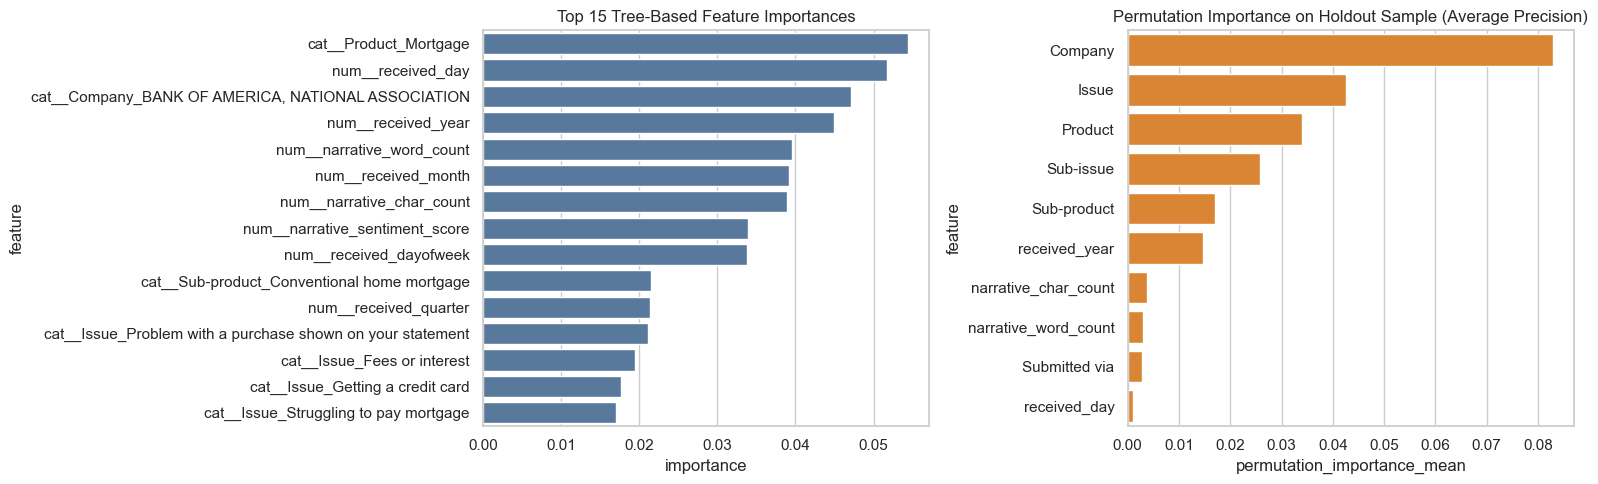

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=feature_importance_df.head(15), x="importance", y="feature", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 15 Tree-Based Feature Importances")

sns.barplot(data=perm_df.head(10), x="permutation_importance_mean", y="feature", ax=axes[1], color="#F58518")
axes[1].set_title("Permutation Importance on Holdout Sample (Average Precision)")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_feature_importance_plots.png", dpi=200, bbox_inches="tight")


A strong evaluation should connect importance results back to modeling choices. In the final monetary-relief notebook, the key question is whether complaint context, company context, and simple narrative features explain most of the signal once geography is removed and cumulative time indexing is excluded. Using average precision for permutation importance also makes the ranking more informative for an imbalanced binary outcome than a thresholded F1-based shuffle test.


### Ablation Analysis

Ablation testing measures how much the model depends on different groups of features. To keep runtime reasonable, this section uses a 3-fold CV summary on the training set and compares F1 after removing one feature family at a time.


In [7]:
feature_groups = {
    "all_features": rf_features,
    "no_narrative_size": [f for f in rf_features if f not in {"narrative_char_count", "narrative_word_count"}],
    "no_sentiment": [f for f in rf_features if f != "narrative_sentiment_score"],
    "no_company": [f for f in rf_features if f != "Company"],
    "no_product_context": [f for f in rf_features if f not in {"Product", "Sub-product"}],
    "no_issue_context": [f for f in rf_features if f not in {"Issue", "Sub-issue"}],
}
if topic_cluster_features:
    feature_groups["no_topic_cluster"] = [f for f in rf_features if f not in set(topic_cluster_features)]

ablation_rows = []
fast_cv = StratifiedKFold(n_splits=FAST_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for label, cols in feature_groups.items():
    ablation_pipeline, _, _ = build_rf_pipeline(selected_features=cols, **best_rf_params)
    scores = cross_validate(
        ablation_pipeline,
        train_df[cols],
        y_train,
        scoring={"f1": "f1", "recall": "recall", "precision": "precision"},
        cv=fast_cv,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    ablation_rows.append(
        {
            "ablation": label,
            "cv_mean_f1": scores["test_f1"].mean(),
            "cv_mean_precision": scores["test_precision"].mean(),
            "cv_mean_recall": scores["test_recall"].mean(),
            "feature_count": len(cols),
        }
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("cv_mean_f1", ascending=False).reset_index(drop=True)
baseline_f1 = ablation_df.loc[ablation_df["ablation"].eq("all_features"), "cv_mean_f1"].iloc[0]
ablation_df["f1_drop_vs_all_features"] = baseline_f1 - ablation_df["cv_mean_f1"]
ablation_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_ablation_results.csv", index=False)
display(ablation_df)


,ablation,cv_mean_f1,cv_mean_precision,cv_mean_recall,feature_count,f1_drop_vs_all_features
0,no_narrative_size,0.420266,0.317815,0.620297,13,-0.001365
1,no_sentiment,0.419231,0.320734,0.605167,14,-0.000331
2,all_features,0.418900,0.325070,0.589032,15,0.000000
3,no_product_context,0.418163,0.325334,0.585271,13,0.000737
4,no_issue_context,0.357268,0.295367,0.452182,13,0.061632
5,no_company,0.327825,0.283135,0.389317,14,0.091075


### Sensitivity Analysis

Sensitivity analysis helps us understand whether the selected Random Forest is stable or fragile. Here we vary two influential hyperparameters, `max_depth` and `min_samples_leaf`, and track cross-validated F1. A stable model should not collapse from small changes around the selected setting.


,max_depth,min_samples_leaf,cv_mean_f1,cv_mean_precision,cv_mean_recall
6,None,2,0.410902,0.327844,0.550435
7,None,5,0.409182,0.294886,0.668340
3,22,2,0.408223,0.290044,0.689776
4,22,5,0.398969,0.274970,0.727293
8,None,10,0.398917,0.275420,0.723511
5,22,10,0.390545,0.263664,0.753459
0,14,2,0.376005,0.248717,0.772056
1,14,5,0.375825,0.246518,0.792548
2,14,10,0.370823,0.241892,0.795701


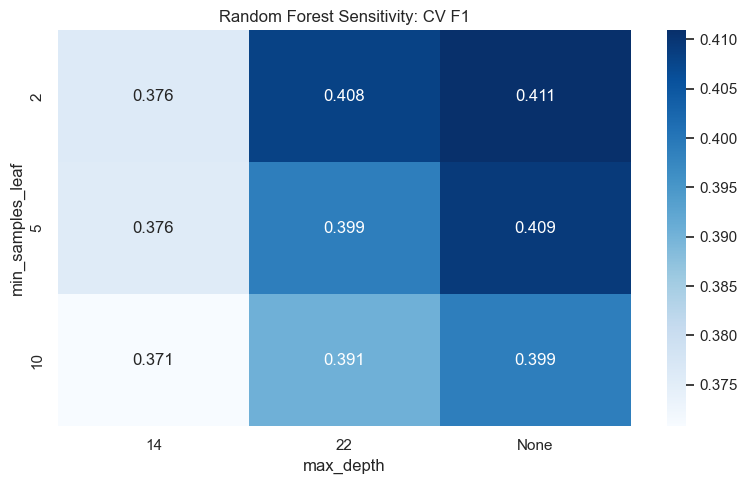

In [8]:
sensitivity_rows = []
sensitivity_train_df = train_df.sample(n=min(25000, len(train_df)), random_state=RANDOM_STATE)
sensitivity_y = sensitivity_train_df[target_col]
for max_depth in [14, 22, None]:
    for min_samples_leaf in [2, 5, 10]:
        pipeline, _, _ = build_rf_pipeline(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=best_rf_params["min_samples_split"],
            max_features=best_rf_params["max_features"],
        )
        scores = cross_validate(
            pipeline,
            sensitivity_train_df[rf_features],
            sensitivity_y,
            scoring={"f1": "f1", "recall": "recall", "precision": "precision"},
            cv=fast_cv,
            n_jobs=N_JOBS,
            return_train_score=False,
        )
        sensitivity_rows.append(
            {
                "max_depth": str(max_depth),
                "min_samples_leaf": min_samples_leaf,
                "cv_mean_f1": scores["test_f1"].mean(),
                "cv_mean_precision": scores["test_precision"].mean(),
                "cv_mean_recall": scores["test_recall"].mean(),
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(["cv_mean_f1", "cv_mean_recall"], ascending=False)
sensitivity_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_sensitivity_results.csv", index=False)
display(sensitivity_df)

pivot_f1 = sensitivity_df.pivot(index="min_samples_leaf", columns="max_depth", values="cv_mean_f1")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="Blues")
plt.title("Random Forest Sensitivity: CV F1")
plt.ylabel("min_samples_leaf")
plt.xlabel("max_depth")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_sensitivity_heatmap.png", dpi=200, bbox_inches="tight")


### Tradeoff Analysis

Tradeoff analysis asks how the Random Forest behaves when we change decision thresholds or training data size. This is still useful even with a more balanced target, because threshold shifts can change the precision-recall tradeoff materially.


,setting,accuracy,precision,recall,f1,balanced_accuracy,average_precision
0,default_0.50,0.793292,0.323477,0.603477,0.421188,0.711896,0.364464
1,best_f1_0.480,0.782750,0.317578,0.646941,0.426024,0.724513,0.364464


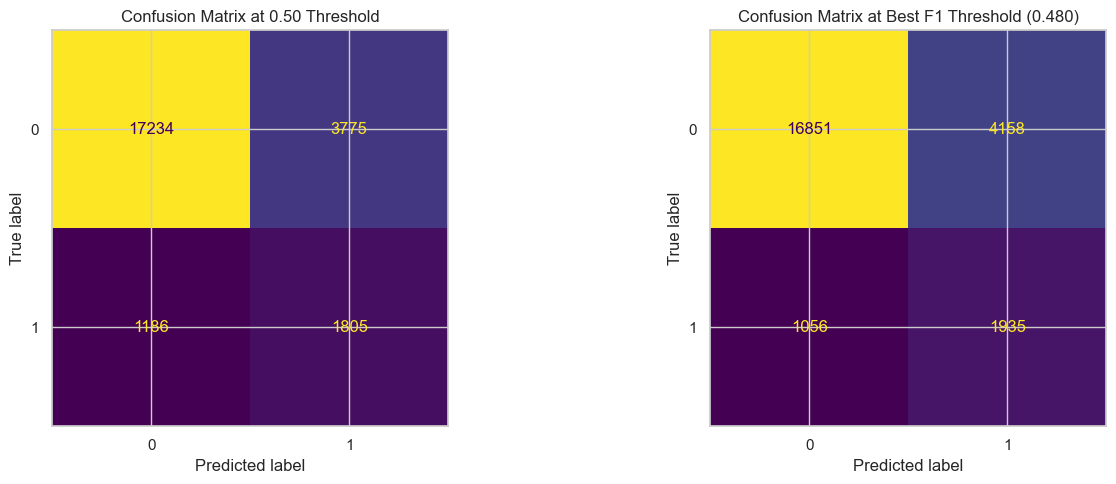

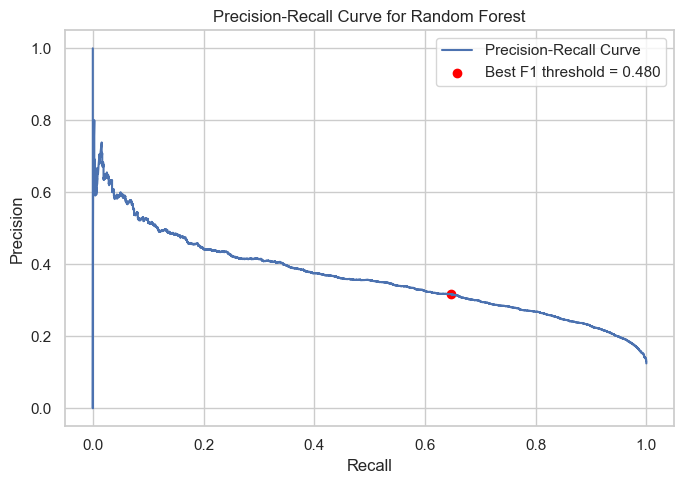

In [9]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba)
threshold_f1 = np.divide(
    2 * precisions[:-1] * recalls[:-1],
    precisions[:-1] + recalls[:-1],
    out=np.zeros_like(precisions[:-1]),
    where=(precisions[:-1] + recalls[:-1]) != 0,
)
best_threshold_idx = int(np.argmax(threshold_f1))
best_threshold = float(thresholds[best_threshold_idx])
threshold_pred = (test_proba >= best_threshold).astype(int)
threshold_metrics = score_predictions(y_test, threshold_pred, test_proba)

threshold_tradeoff_df = pd.DataFrame(
    {
        "setting": ["default_0.50", f"best_f1_{best_threshold:.3f}"],
        "accuracy": [holdout_metrics["accuracy"], threshold_metrics["accuracy"]],
        "precision": [holdout_metrics["precision"], threshold_metrics["precision"]],
        "recall": [holdout_metrics["recall"], threshold_metrics["recall"]],
        "f1": [holdout_metrics["f1"], threshold_metrics["f1"]],
        "balanced_accuracy": [holdout_metrics["balanced_accuracy"], threshold_metrics["balanced_accuracy"]],
        "average_precision": [holdout_metrics["average_precision"], threshold_metrics["average_precision"]],
    }
)
threshold_tradeoff_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_threshold_tradeoff.csv", index=False)
display(threshold_tradeoff_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix at 0.50 Threshold")
ConfusionMatrixDisplay.from_predictions(y_test, threshold_pred, ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix at Best F1 Threshold ({best_threshold:.3f})")
plt.tight_layout()
fig.savefig(VISUALS_DIR / "04_final_confusion_matrices.png", dpi=200, bbox_inches="tight")

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label="Precision-Recall Curve")
plt.scatter(recalls[best_threshold_idx], precisions[best_threshold_idx], color="red", label=f"Best F1 threshold = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_precision_recall_curve.png", dpi=200, bbox_inches="tight")


,train_size,train_f1_mean,validation_f1_mean
0,3333,0.700951,0.364455
1,6666,0.684597,0.393535
2,9999,0.665240,0.398488
3,13332,0.658036,0.408023
4,16666,0.646401,0.407811


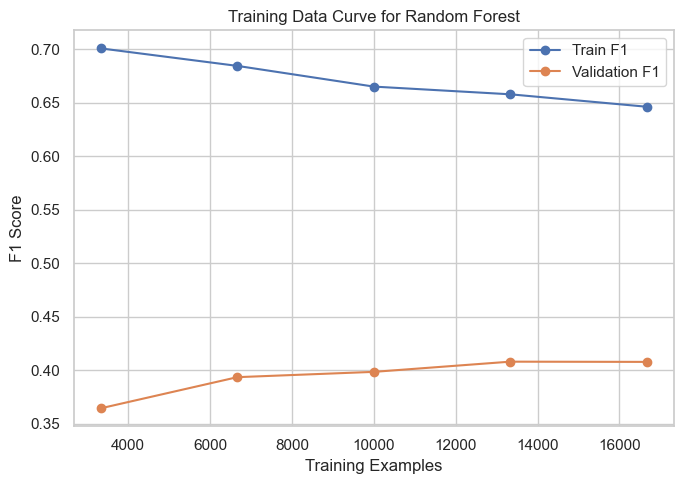

In [10]:
curve_train_df = train_df.sample(n=min(25000, len(train_df)), random_state=RANDOM_STATE)
curve_y = curve_train_df[target_col]
curve_pipeline, _, _ = build_rf_pipeline(**best_rf_params)
train_sizes, train_scores, valid_scores = learning_curve(
    curve_pipeline,
    curve_train_df[rf_features],
    curve_y,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=fast_cv,
    scoring="f1",
    n_jobs=N_JOBS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

learning_curve_df = pd.DataFrame(
    {
        "train_size": train_sizes,
        "train_f1_mean": train_scores.mean(axis=1),
        "validation_f1_mean": valid_scores.mean(axis=1),
    }
)
learning_curve_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_learning_curve.csv", index=False)
display(learning_curve_df)

plt.figure(figsize=(7, 5))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_f1_mean"], marker="o", label="Train F1")
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_f1_mean"], marker="o", label="Validation F1")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.title("Training Data Curve for Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_learning_curve.png", dpi=200, bbox_inches="tight")


This section captures multiple project-required tradeoffs:

- precision versus recall as the classification threshold changes
- conservative default thresholding versus threshold tuning for minority-class detection
- training data size versus validation F1 through the learning curve

Together, these analyses help explain whether the model is limited more by representation, thresholding, or simply available data.


### Failure Analysis

Failure analysis focuses on specific mistakes rather than aggregate metrics. To satisfy the assignment requirement, we select at least three concrete failed predictions and group them into different categories. The goal is not just to note the error, but to reason about why it likely occurred and what future improvements could address it.


In [11]:
failure_df = test_df[[
    "Complaint ID",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "Submitted via",
    "Consumer complaint narrative",
    target_col,
]].copy()
failure_df["predicted_label"] = test_pred
failure_df["predicted_proba"] = test_proba
failure_df["error_type"] = np.where(
    (failure_df[target_col] == 1) & (failure_df["predicted_label"] == 0),
    "false_negative",
    np.where(
        (failure_df[target_col] == 0) & (failure_df["predicted_label"] == 1),
        "false_positive",
        "correct",
    ),
)
failure_df["narrative_present"] = failure_df["Consumer complaint narrative"].fillna("").str.len().gt(0)
failure_df["narrative_word_count"] = failure_df["Consumer complaint narrative"].fillna("").str.split().str.len().fillna(0)

false_negative_examples = failure_df.loc[failure_df["error_type"].eq("false_negative")].sort_values("predicted_proba", ascending=False)
false_positive_examples = failure_df.loc[failure_df["error_type"].eq("false_positive")].sort_values("predicted_proba", ascending=False)

failure_examples = pd.concat(
    [
        false_negative_examples.head(1).assign(failure_category="likely systematic minority-class miss"),
        false_positive_examples.head(1).assign(failure_category="aggressive positive flag / ambiguous case"),
        false_negative_examples.sort_values("narrative_word_count").head(1).assign(failure_category="sparse-information edge case"),
    ],
    axis=0,
).drop_duplicates(subset=["Complaint ID"]).reset_index(drop=True)

failure_examples.to_csv(OUTPUT_TABLES_DIR / "04_final_failure_examples.csv", index=False)
display(failure_examples[[
    "Complaint ID",
    "failure_category",
    "error_type",
    target_col,
    "predicted_label",
    "predicted_proba",
    "Product",
    "Issue",
    "Sub-issue",
    "Company",
    "Submitted via",
    "narrative_present",
    "narrative_word_count",
]])


,Complaint ID,failure_category,error_type,target_relief,predicted_label,predicted_proba,Product,Issue,Sub-issue,Company,Submitted via,narrative_present,narrative_word_count
0,4558933,likely systematic minority-class miss,false_negative,1,0,0.499944,Checking or savings account,Managing an account,Banking errors,"BANK OF AMERICA, NATIONAL ASSOCIATION",Phone,False,0
1,2807632,aggressive positive flag / ambiguous case,false_positive,0,1,0.906361,Checking or savings account,Problem caused by your funds being low,Overdrafts and overdraft fees,"BANK OF AMERICA, NATIONAL ASSOCIATION",Referral,False,0
2,3429036,sparse-information edge case,false_negative,1,0,0.490466,Credit card or prepaid card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,SYNCHRONY FINANCIAL,Postal mail,False,0


Use the displayed failure cases to write the final report narrative in a structured way:

1. Describe the record and the incorrect prediction.
2. Note whether the failure looks more like a systematic minority-class miss, an edge case with weak information, or an overly aggressive positive flag.
3. Connect that failure back to evidence from feature importance, threshold analysis, or data imbalance.
4. Propose a future fix, such as threshold adjustment, richer narrative features, additional data, or different sampling/ensemble strategies.

Practical interpretation hints:

- False negatives usually support the argument that the default threshold is conservative or that rare-class signal is underrepresented.
- False positives often suggest overlapping patterns between timely and untimely complaints for certain issue or company contexts.
- Very short or missing narratives can create edge cases because the model has less descriptive context available, even when simple narrative indicators are included.


### Conclusions

This notebook covers the main evaluation requirements for the selected final Random Forest:

- overall model comparison via the saved cross-validated development table
- detailed evaluation using cross-validation plus holdout metrics
- feature importance and feature-group ablation
- hyperparameter sensitivity analysis
- threshold and training-data tradeoff analysis
- concrete failure examples and future-improvement directions

The most important report-level takeaways should now be easier to frame:

- whether issue context, company context, and lightweight narrative features carry most of the monetary-relief signal
- whether removing geography was the right simplification
- whether threshold tuning meaningfully improves F1 and recall for the positive monetary-relief class
- whether the learning curve suggests more data will still help, or whether feature quality is now the bigger bottleneck
